# Prueba sintética: `L` adaptativo por floor y por `tau`

Este notebook genera datos sintéticos Heston y compara:
- Caso base: `COS(N, L)` fijo.
- Caso adaptativo: retry con `L` aumentado cuando:
  - la `implied volatility` cae en el floor, o
  - `tau < 0.25`.

Incluye un análisis simple de:
- cuántos puntos mejoran (dejan de estar pegados al floor),
- qué pasa en los puntos con `tau` pequeño cuando cambia `L`.

Nota: por defecto usa `10_000` muestras. Para pruebas rápidas se puede usar variables de entorno:
- `ADAPTIVE_L_N_SAMPLES`
- `ADAPTIVE_L_COS_N`
- `ADAPTIVE_L_COS_L`


In [18]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')


In [19]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'configs' / 'synth.yaml').exists() and (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError('No se encontró el root del proyecto (configs/synth.yaml).')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'synth.yaml'
with CONFIG_PATH.open('r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

PROJECT_ROOT


PosixPath('/Users/jenriquezafra/Proyectos/Dev/python/TFM/TFM')

In [20]:
from src.datasets.make_synth import generate_all
from src.solvers.heston_cos import _cos_integration_bounds
from src.solvers.implied_vol import IV_Brent


In [21]:
def as_bounds(value):
    if isinstance(value, (list, tuple)) and len(value) == 2:
        lo = np.float64(value[0])
        hi = np.float64(value[1])
        if lo > hi:
            raise ValueError(f'Bounds invalidos: {lo} > {hi}')
        if lo == hi:
            hi = np.nextafter(lo, np.inf)
        return np.array([lo, hi], dtype=np.float64)
    lo = np.float64(value)
    hi = np.nextafter(lo, np.inf)
    return np.array([lo, hi], dtype=np.float64)


def iv_at_floor(iv: float, floor_iv: float, rel_tol: float) -> bool:
    if (not np.isfinite(iv)) or (not np.isfinite(floor_iv)):
        return False
    threshold = np.float64(floor_iv * (1.0 + max(0.0, rel_tol)))
    return bool(iv <= threshold)


def retry_improves_solution(
    base_iv: float,
    base_residual_abs: float,
    retry_iv: float,
    retry_residual_abs: float,
    floor_iv: float,
    floor_rel_tol: float,
) -> bool:
    base_floor = iv_at_floor(base_iv, floor_iv, floor_rel_tol)
    retry_floor = iv_at_floor(retry_iv, floor_iv, floor_rel_tol)

    if base_floor and (not retry_floor):
        return True
    if retry_floor and (not base_floor):
        return False

    base_ok = np.isfinite(base_residual_abs)
    retry_ok = np.isfinite(retry_residual_abs)
    if retry_ok and base_ok:
        return bool(retry_residual_abs <= base_residual_abs)
    if retry_ok and (not base_ok):
        return True
    return False


def cos_interval_has_sign_change(
    params_heston: np.ndarray,
    tau: float,
    r: float,
    cos_l: float,
    interval_rule: str,
) -> bool:
    try:
        a, b = _cos_integration_bounds(
            params_Heston=np.array(params_heston, dtype=np.float64),
            tau=np.float64(tau),
            r=np.float64(r),
            L=np.float64(cos_l),
            t0=0.0,
            interval_rule=interval_rule,
        )
    except Exception:
        return False

    if (not np.isfinite(a)) or (not np.isfinite(b)) or (b <= a):
        return False
    return bool((a <= 0.0) and (b >= 0.0))


In [22]:
# Parametros del experimento
N_SAMPLES = int(os.getenv('ADAPTIVE_L_N_SAMPLES', '10000'))
SEED = int(cfg['meta']['seed'])

TAU_CUTOFF = 0.25
_adaptive_cfg = cfg['quality_check'].get('adaptive_cos_l_retry', cfg['quality_check'].get('adaptive_cos_floor_retry', {}))
FLOOR_REL_TOL = float(_adaptive_cfg.get('floor_rel_tol', 1.0e-6))
L_MULTIPLIER = float(_adaptive_cfg.get('l_multiplier', 1.5))
MAX_RETRIES = int(_adaptive_cfg.get('max_retries', 1))

ADAPTIVE_TRIGGER_FLOOR = bool(_adaptive_cfg.get('trigger_floor', True))
ADAPTIVE_TRIGGER_TAU_THRESHOLD = _adaptive_cfg.get('trigger_tau_below', TAU_CUTOFF)
if ADAPTIVE_TRIGGER_TAU_THRESHOLD is not None:
    ADAPTIVE_TRIGGER_TAU_THRESHOLD = float(ADAPTIVE_TRIGGER_TAU_THRESHOLD)
ADAPTIVE_REQUIRE_SIGN_CHANGE = bool(_adaptive_cfg.get('require_sign_change', False))

ROOTFINDER_CFG = cfg['root_finder']['methods']['brent_iv']
IV_BOUNDS = tuple(ROOTFINDER_CFG['iv_bounds'])
FLOOR_IV = float(IV_BOUNDS[0])

COS_N = int(os.getenv('ADAPTIVE_L_COS_N', str(cfg['cos_solver']['N'])))
COS_L = float(os.getenv('ADAPTIVE_L_COS_L', str(cfg['cos_solver']['L'])))
COS_INTERVAL_RULE = cfg['cos_solver'].get('interval_rule', 'sqrt_t')

OPT_TYPE = cfg['market'].get('option_type', 'put')
K = float(cfg['market'].get('K', 1.0))

PARAM_ORDER = ['rho', 'kappa', 'gamma', 'bar_v', 'v0']
FEATURE_COLS = PARAM_ORDER + ['moneyness', 'tau', 'r']

print(f'N_SAMPLES={N_SAMPLES} | COS_N={COS_N} | COS_L={COS_L}')
print(
    f'Trigger adaptativo: floor={ADAPTIVE_TRIGGER_FLOOR}, '
    f'tau<{ADAPTIVE_TRIGGER_TAU_THRESHOLD}, require_sign_change={ADAPTIVE_REQUIRE_SIGN_CHANGE}'
)


N_SAMPLES=10000 | COS_N=1500 | COS_L=50.0
Trigger adaptativo: floor=True, tau<0.25, require_sign_change=True


In [23]:
# Bounds desde la config
params_cfg = cfg['data']['heston_params']
grid_cfg = cfg['data']['grid']
market_cfg = cfg['market']

params_bounds = np.array(
    [
        as_bounds(params_cfg['rho']),
        as_bounds(params_cfg['kappa']),
        as_bounds(params_cfg['gamma']),
        as_bounds(params_cfg['bar_v']),
        as_bounds(params_cfg['v0']),
    ],
    dtype=np.float64,
)

grid_bounds = np.array(
    [
        as_bounds(grid_cfg['moneyness']),
        as_bounds(grid_cfg['tau']),
    ],
    dtype=np.float64,
)

r_bounds = as_bounds(market_cfg['r'])

X_params, X_grid, X_r = generate_all(
    n_samples=N_SAMPLES,
    param_ranges=params_bounds,
    grid_bounds=grid_bounds,
    r_bounds=r_bounds,
    seed=SEED,
)

X = np.hstack([X_params, X_grid, X_r])
df = pd.DataFrame(X, columns=FEATURE_COLS)
df.head()


,rho,kappa,gamma,bar_v,v0,moneyness,tau,r
0,-0.489400,2.343468,0.685935,0.103458,0.322066,1.200402,1.943085,0.027556
1,-0.656562,2.017965,0.518573,0.299251,0.479721,0.681214,2.413409,0.027904
2,-0.208850,2.515781,0.299075,0.446510,0.247696,1.236612,2.629194,0.029016
3,-0.052900,1.214642,0.237483,0.281213,0.142153,1.076265,1.135675,0.043890
4,-0.513119,0.547689,0.777132,0.308793,0.326834,1.022042,0.224868,0.028447


In [24]:
def solve_iv_with_details(row: pd.Series, cos_n: int, cos_l: float):
    params_heston = row[PARAM_ORDER].to_numpy(dtype=np.float64)
    S0 = np.float64(row['moneyness'])
    tau = np.float64(row['tau'])
    r = np.float64(row['r'])

    iv, details = IV_Brent(
        params_Heston=params_heston,
        S0=S0,
        K=np.float64(K),
        tau=tau,
        r=r,
        COS_params=np.array([cos_n, cos_l], dtype=np.float64),
        opt_type=OPT_TYPE,
        cos_interval_rule=COS_INTERVAL_RULE,
        iv_bounds=IV_BOUNDS,
        tol=float(ROOTFINDER_CFG['tol']),
        max_iter=int(ROOTFINDER_CFG['max_iter']),
        return_details=True,
    )
    return float(iv), details


In [25]:
records = []

for i, row in df.iterrows():
    base_iv = np.nan
    base_res = np.nan
    final_iv = np.nan
    final_res = np.nan

    trigger_floor = False
    trigger_tau = False
    trigger_any = False
    retry_accepted = False
    retry_attempts = 0
    l_used = float(COS_L)

    sign_change_base = False
    sign_change_final = False

    try:
        base_iv, base_details = solve_iv_with_details(row, cos_n=COS_N, cos_l=COS_L)
        base_res = float(base_details.get('price_residual_abs', np.nan))

        params_heston = row[PARAM_ORDER].to_numpy(dtype=np.float64)
        tau = float(row['tau'])
        r = float(row['r'])

        sign_change_base = cos_interval_has_sign_change(
            params_heston=params_heston,
            tau=tau,
            r=r,
            cos_l=COS_L,
            interval_rule=COS_INTERVAL_RULE,
        )
        sign_change_final = sign_change_base

        trigger_floor = ADAPTIVE_TRIGGER_FLOOR and iv_at_floor(base_iv, FLOOR_IV, FLOOR_REL_TOL)
        trigger_tau = (ADAPTIVE_TRIGGER_TAU_THRESHOLD is not None) and (tau < ADAPTIVE_TRIGGER_TAU_THRESHOLD)
        trigger_any = trigger_floor or trigger_tau

        final_iv = float(base_iv)
        final_res = float(base_res)

        if trigger_any:
            active_l = float(COS_L)
            best_iv = float(base_iv)
            best_res = float(base_res)
            best_sign_change = bool(sign_change_base)

            for _ in range(max(1, MAX_RETRIES)):
                retry_attempts += 1
                retry_l = float(active_l * L_MULTIPLIER)
                if L_MULTIPLIER > 1.0 and retry_l <= active_l:
                    retry_l = np.nextafter(active_l, np.inf)
                active_l = retry_l

                try:
                    retry_iv, retry_details = solve_iv_with_details(row, cos_n=COS_N, cos_l=retry_l)
                    retry_res = float(retry_details.get('price_residual_abs', np.nan))
                except Exception:
                    continue

                retry_sign_change = cos_interval_has_sign_change(
                    params_heston=params_heston,
                    tau=tau,
                    r=r,
                    cos_l=retry_l,
                    interval_rule=COS_INTERVAL_RULE,
                )

                if ADAPTIVE_REQUIRE_SIGN_CHANGE and (not retry_sign_change):
                    continue

                accept_retry = False
                if ADAPTIVE_REQUIRE_SIGN_CHANGE and (not best_sign_change) and retry_sign_change:
                    accept_retry = True
                elif retry_improves_solution(
                    base_iv=best_iv,
                    base_residual_abs=best_res,
                    retry_iv=retry_iv,
                    retry_residual_abs=retry_res,
                    floor_iv=FLOOR_IV,
                    floor_rel_tol=FLOOR_REL_TOL,
                ):
                    accept_retry = True

                if accept_retry:
                    best_iv = float(retry_iv)
                    best_res = float(retry_res)
                    best_sign_change = bool(retry_sign_change)
                    l_used = float(retry_l)
                    retry_accepted = True

            final_iv = float(best_iv)
            final_res = float(best_res)
            sign_change_final = bool(best_sign_change)

    except Exception:
        pass

    records.append(
        {
            'base_iv': base_iv,
            'final_iv': final_iv,
            'base_residual_abs': base_res,
            'final_residual_abs': final_res,
            'trigger_floor': trigger_floor,
            'trigger_tau': trigger_tau,
            'trigger_any': trigger_any,
            'retry_attempts': retry_attempts,
            'retry_accepted': retry_accepted,
            'cos_l_used': l_used,
            'interval_sign_change_base': sign_change_base,
            'interval_sign_change_final': sign_change_final,
        }
    )

    if (i + 1) % 500 == 0:
        print(f'Procesadas {i+1}/{N_SAMPLES}')

result = pd.concat([df.reset_index(drop=True), pd.DataFrame(records)], axis=1)

result['base_floor'] = result['base_iv'].apply(lambda x: iv_at_floor(x, FLOOR_IV, FLOOR_REL_TOL))
result['final_floor'] = result['final_iv'].apply(lambda x: iv_at_floor(x, FLOOR_IV, FLOOR_REL_TOL))
result['improved_from_floor'] = result['base_floor'] & (~result['final_floor'])
result['delta_iv'] = result['final_iv'] - result['base_iv']
result['delta_residual_abs'] = result['final_residual_abs'] - result['base_residual_abs']

result.head()


Procesadas 500/10000
Procesadas 1000/10000
Procesadas 1500/10000
Procesadas 2000/10000
Procesadas 2500/10000
Procesadas 3000/10000
Procesadas 3500/10000
Procesadas 4000/10000
Procesadas 4500/10000
Procesadas 5000/10000
Procesadas 5500/10000
Procesadas 6000/10000
Procesadas 6500/10000
Procesadas 7000/10000
Procesadas 7500/10000
Procesadas 8000/10000
Procesadas 8500/10000
Procesadas 9000/10000
Procesadas 9500/10000
Procesadas 10000/10000


,rho,kappa,gamma,bar_v,v0,moneyness,tau,r,base_iv,final_iv,...,retry_attempts,retry_accepted,cos_l_used,interval_sign_change_base,interval_sign_change_final,base_floor,final_floor,improved_from_floor,delta_iv,delta_residual_abs
0,-0.489400,2.343468,0.685935,0.103458,0.322066,1.200402,1.943085,0.027556,0.384553,0.384553,...,0,False,50.0,True,True,False,False,False,0.000000e+00,0.000000e+00
1,-0.656562,2.017965,0.518573,0.299251,0.479721,0.681214,2.413409,0.027904,0.540411,0.540411,...,0,False,50.0,True,True,False,False,False,0.000000e+00,0.000000e+00
2,-0.208850,2.515781,0.299075,0.446510,0.247696,1.236612,2.629194,0.029016,0.642837,0.642837,...,0,False,50.0,True,True,False,False,False,0.000000e+00,0.000000e+00
3,-0.052900,1.214642,0.237483,0.281213,0.142153,1.076265,1.135675,0.043890,0.451574,0.451574,...,0,False,50.0,True,True,False,False,False,0.000000e+00,0.000000e+00
4,-0.513119,0.547689,0.777132,0.308793,0.326834,1.022042,0.224868,0.028447,0.560930,0.560930,...,3,True,112.5,True,True,False,False,False,-1.596501e-13,-1.942890e-16


In [26]:
summary = {
    'n_total': len(result),
    'n_trigger_any': int(result['trigger_any'].sum()),
    'n_trigger_floor': int(result['trigger_floor'].sum()),
    'n_trigger_tau': int(result['trigger_tau'].sum()),
    'n_trigger_both': int((result['trigger_floor'] & result['trigger_tau']).sum()),
    'n_retry_accepted': int(result['retry_accepted'].sum()),
    'n_base_floor': int(result['base_floor'].sum()),
    'n_final_floor': int(result['final_floor'].sum()),
    'n_improved_from_floor': int(result['improved_from_floor'].sum()),
    'n_sign_change_base': int(result['interval_sign_change_base'].sum()),
    'n_sign_change_final': int(result['interval_sign_change_final'].sum()),
    'n_sign_change_fixed': int((~result['interval_sign_change_base'] & result['interval_sign_change_final']).sum()),
}

summary_df = pd.DataFrame([summary]).T.rename(columns={0: 'value'})
summary_df


,value
n_total,10000
n_trigger_any,679
n_trigger_floor,6
n_trigger_tau,678
n_trigger_both,5
n_retry_accepted,539
n_base_floor,6
n_final_floor,6
n_improved_from_floor,0
n_sign_change_base,10000


In [27]:
# Analisis focalizado: puntos con tau pequeño
tau_small = result['tau'] < TAU_CUTOFF
changed_tau_small = tau_small & result['retry_accepted']

tau_analysis = pd.DataFrame(
    {
        'n_tau_small': [int(tau_small.sum())],
        'n_changed_tau_small': [int(changed_tau_small.sum())],
        'pct_changed_tau_small': [100.0 * changed_tau_small.mean()],
        'base_floor_tau_small': [int((tau_small & result['base_floor']).sum())],
        'final_floor_tau_small': [int((tau_small & result['final_floor']).sum())],
        'improved_from_floor_tau_small': [int((tau_small & result['improved_from_floor']).sum())],
        'mean_delta_iv_changed_tau_small': [float(result.loc[changed_tau_small, 'delta_iv'].mean()) if changed_tau_small.any() else np.nan],
        'median_delta_iv_changed_tau_small': [float(result.loc[changed_tau_small, 'delta_iv'].median()) if changed_tau_small.any() else np.nan],
        'mean_delta_resid_changed_tau_small': [float(result.loc[changed_tau_small, 'delta_residual_abs'].mean()) if changed_tau_small.any() else np.nan],
    }
)

tau_analysis.T


,0
n_tau_small,6.780000e+02
n_changed_tau_small,5.380000e+02
pct_changed_tau_small,5.380000e+00
base_floor_tau_small,5.000000e+00
final_floor_tau_small,5.000000e+00
improved_from_floor_tau_small,0.000000e+00
mean_delta_iv_changed_tau_small,-1.120235e-07
median_delta_iv_changed_tau_small,0.000000e+00
mean_delta_resid_changed_tau_small,-9.601288e-17


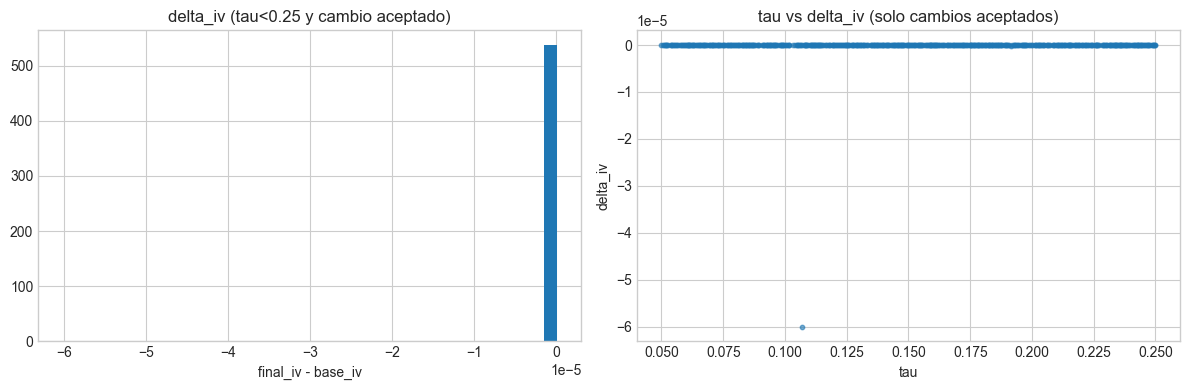

In [28]:
# Visual simple: cambios de IV para tau pequeño que realmente cambiaron
plot_mask = (result['tau'] < TAU_CUTOFF) & result['retry_accepted'] & np.isfinite(result['delta_iv'])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(result.loc[plot_mask, 'delta_iv'], bins=40)
ax[0].set_title('delta_iv (tau<0.25 y cambio aceptado)')
ax[0].set_xlabel('final_iv - base_iv')

ax[1].scatter(
    result.loc[plot_mask, 'tau'],
    result.loc[plot_mask, 'delta_iv'],
    s=10,
    alpha=0.6,
)
ax[1].set_title('tau vs delta_iv (solo cambios aceptados)')
ax[1].set_xlabel('tau')
ax[1].set_ylabel('delta_iv')

plt.tight_layout()
plt.show()


In [29]:
# Tabla corta de ejemplos que mejoraron al salir del floor
cols = [
    'rho', 'kappa', 'gamma', 'bar_v', 'v0', 'moneyness', 'tau', 'r',
    'base_iv', 'final_iv', 'delta_iv', 'base_residual_abs', 'final_residual_abs', 'cos_l_used',
    'trigger_floor', 'trigger_tau', 'retry_accepted',
]

result.loc[result['improved_from_floor'], cols].head(15)


,rho,kappa,gamma,bar_v,v0,moneyness,tau,r,base_iv,final_iv,delta_iv,base_residual_abs,final_residual_abs,cos_l_used,trigger_floor,trigger_tau,retry_accepted


## Lectura rápida esperada

- `n_improved_from_floor` mide exactamente los casos donde la IV deja de estar pegada al floor.
- En `tau_analysis` tienes el foco de `tau < 0.25`:
  - cuántos puntos cambiaron por el `L` adaptativo,
  - cómo cambian IV y residual.
- Si quieres más sensibilidad en `tau` corto, sube `L_MULTIPLIER` o `MAX_RETRIES`.
